# Bank Marketing | ML1 Final Project
## Ethan Ooi, Nathan Myers, Erik Huisman

In [122]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (classification_report, confusion_matrix, ConfusionMatrixDisplay, 
    roc_auc_score, roc_curve, precision_recall_curve, average_precision_score)

## Data Preprocessing

In [123]:
# Read data in
df = pd.read_csv('../data/bank-additional-full.csv', sep=';')

# Remove nulls
df = df[(df['housing'] != 'unknown') & (df['loan'] != 'unknown')]
df = df[df['job'] != 'unknown']
df = df[df['marital'] != 'unknown']
df = df[df['education'] != 'unknown']

# Drop columns
cols_to_drop = ['default', 'duration', 'previous', 'pdays']
df.drop(columns=cols_to_drop, inplace=True)

(df == 'unknown').sum()

age               0
job               0
marital           0
education         0
housing           0
loan              0
contact           0
month             0
day_of_week       0
campaign          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

In [124]:
# Split feature & target data
X = df.drop(columns=['y'])
y = (df['y'] == 'yes').astype(int)

# Assign categorical & numeric columns
categorical_cols = ['job', 'marital', 'education', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']
numeric_cols = [c for c in X.columns if c not in categorical_cols]

print('Prevalence:', y.mean().round(3))

Prevalence: 0.111


## Logistic Regression

In [125]:
# Train test split data
X_train_log, X_test_log, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

## Why Do We Scale Features?

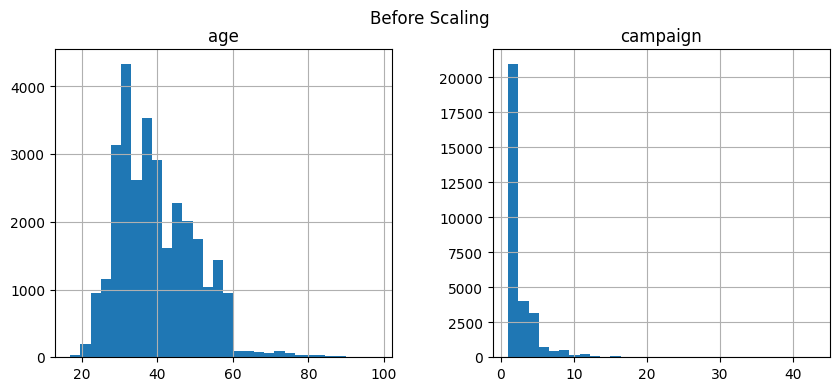

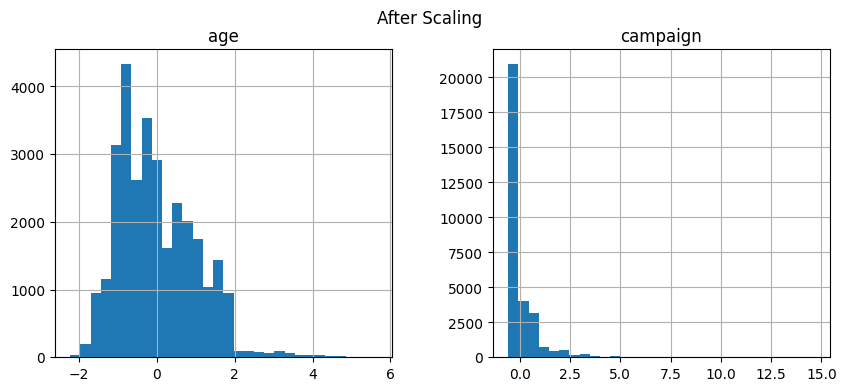

In [126]:
plot_cols = ['age', 'campaign']
X_train_log[plot_cols].hist(bins=30, figsize=(10, 4))
plt.suptitle('Before Scaling')
plt.show()

scaled = StandardScaler().fit_transform(X_train_log[plot_cols])
pd.DataFrame(scaled, columns=plot_cols).hist(bins=30, figsize=(10, 4))
plt.suptitle('After Scaling')
plt.show()

Since some numerical features can be heavily skewed, like 'age' and 'campaign', this can make logistic regression highly sensitive to how these features can be scaled, as features with large scales could potentially dominate the regression process. By adjusting the values on the axes, which is a key aspect of scaling, we can ensure that each feature is on a reasonable scale and the model will converge reliably without any hiccups, despite the overall shape of the distribution appearing to have not changed much.

## Default LogReg

In [127]:
# Numeric Columns
numeric_pipeline = Pipeline([
    ('scaler', StandardScaler())
])

# Categorical Columns
categorical_pipeline = Pipeline([
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

# Combining Pipelines
preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_cols),
    ('cat', categorical_pipeline, categorical_cols)
])

# Making the Full Pipeline
log_pipeline = Pipeline([
    ('prep', preprocessor),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])

# Fit default LogReg model
log_pipeline.fit(X_train_log, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains s

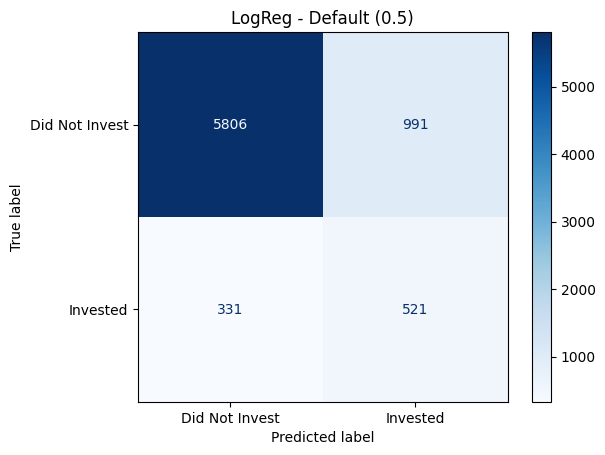

                precision    recall  f1-score   support

Did Not Invest      0.946     0.854     0.898      6797
      Invested      0.345     0.612     0.441       852

      accuracy                          0.827      7649
     macro avg      0.645     0.733     0.669      7649
  weighted avg      0.879     0.827     0.847      7649



In [ ]:
# Evaluate default LogReg
def evaluate(model, X_test, y_test, name):
    global y_pred, y_prob
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    ConfusionMatrixDisplay(
        confusion_matrix=confusion_matrix(y_test, y_pred),
        display_labels=['Did Not Invest', 'Invested']
    ).plot(cmap='Blues')
    plt.title(name)
    plt.show()
    
    print(classification_report(y_test, y_pred, target_names=['Did Not Invest', 'Invested'], digits=3)
)

evaluate(log_pipeline, X_test_log, y_test, "LogReg - Default (0.50)")

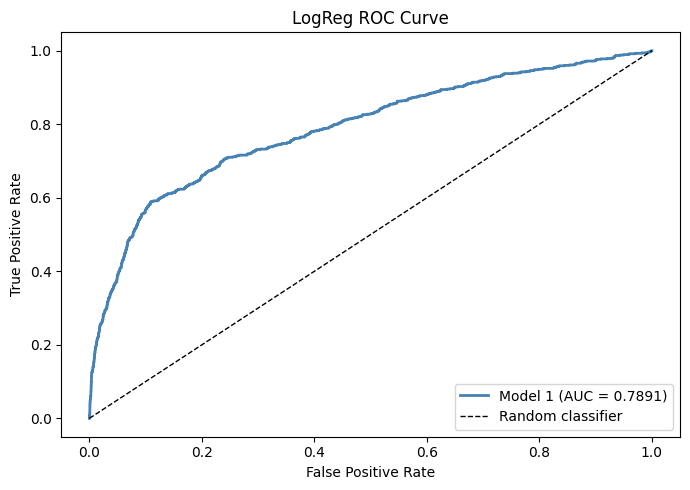

Model 1 ROC-AUC: 0.7891


In [129]:
# ROC AUC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, lw=2, color='steelblue', label=f'Model 1 (AUC = {auc:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('LogReg ROC Curve')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f"Model 1 ROC-AUC: {auc:.4f}")

From what we can see, the model is picking up potential investors, but it still missing out on a large number of investors through misidentifcation. Mislabeling someone who isn't going to invest as a potential investor isn't great either, but it isn't as concerning as labeling a potential investor as someone not worth targeting. As a result, we need to re-tune the model to be more accurate at labeling future investors.

## Lowering the Threshold of our Model

### Threshold tuning
Since false negatives (missing a real investor) cost more than false positives, we lower the threshold to 0.35 to boost recall.

In [130]:
def evaluate_tune(threshold, y_prob, y_test, name):
    y_pred_tuned = (y_prob >= threshold).astype(int)
    ConfusionMatrixDisplay(
        confusion_matrix=confusion_matrix(y_test, y_pred_tuned),
        display_labels=['Did Not Invest', 'Invested']
    ).plot(cmap='Blues')
    plt.title(name)
    plt.show()
    
    print(classification_report(y_test, y_pred_tuned, target_names=['Did Not Invest', 'Invested']))

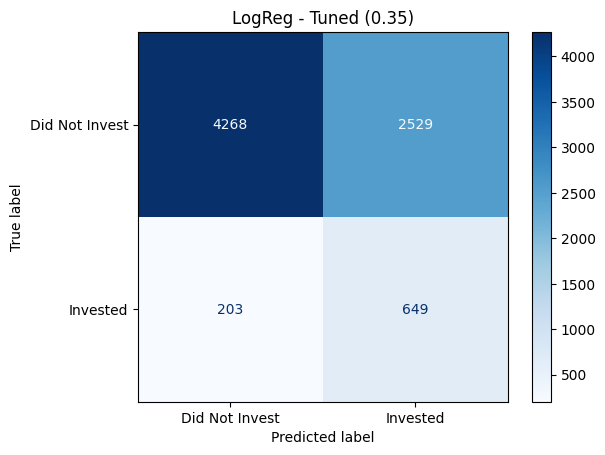

                precision    recall  f1-score   support

Did Not Invest       0.95      0.63      0.76      6797
      Invested       0.20      0.76      0.32       852

      accuracy                           0.64      7649
     macro avg       0.58      0.69      0.54      7649
  weighted avg       0.87      0.64      0.71      7649



In [131]:
threshold = 0.35
evaluate_tune(threshold, y_prob, y_test, "LogReg - Tuned (0.35)")
y_pred_tuned = (y_prob >= threshold).astype(int)

We've dramatically lowered the number of potential investors we've missed out on, however it did come at the cost of lowering the precision of identifying these potential investors. Nonetheless, we are able to encapsulate more investors by lowering the threshold of our model.

## Precision-Recall Curve For Better Understanding

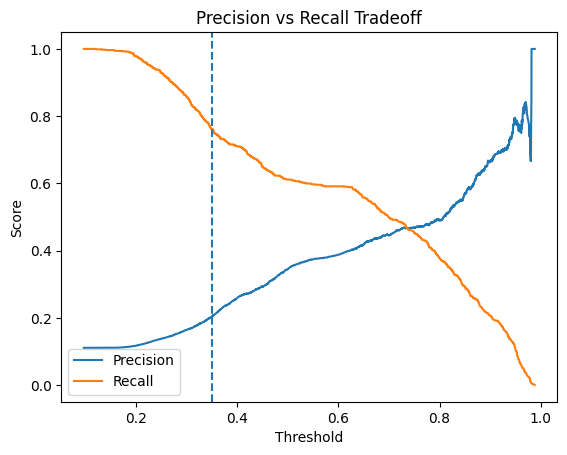

In [132]:
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)
plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.axvline(x=threshold, linestyle='--')
plt.xlabel('Threshold'); plt.ylabel('Score')
plt.title('Precision vs Recall Tradeoff')
plt.legend()
plt.show()

## LogReg GridSearchCV 
Now that we have established a baseline for our model with a threshold of 0.35, we want to tune the hyperparameters for our logistic regression model. By using GridSearchCV, we aren't going to just randomly guess what to tune the paramters to, instead, GridSearchCV allows us to test different combinations using cross-validation and select the model configuration that maximizes our recall since we want to capture as many potential investors as possible. 

In [133]:
log_param_grid = {
    'model__C': [0.01, 0.025, 0.05, 0.1],
    'model__solver': ['lbfgs', 'liblinear', 'saga']
}

log_grid = GridSearchCV(
    log_pipeline, 
    log_param_grid, 
    cv=10, 
    scoring='recall',
    n_jobs=-1,
    verbose=1
)

log_grid.fit(X_train_log, y_train)

best_pipeline = log_grid.best_estimator_
print("Best Parameters:", log_grid.best_params_)
print(f"Best Cross-Validated Recall: {log_grid.best_score_:.4f}")

Fitting 10 folds for each of 12 candidates, totalling 120 fits


Best Parameters: {'model__C': 0.05, 'model__solver': 'liblinear'}
Best Cross-Validated Recall: 0.6201


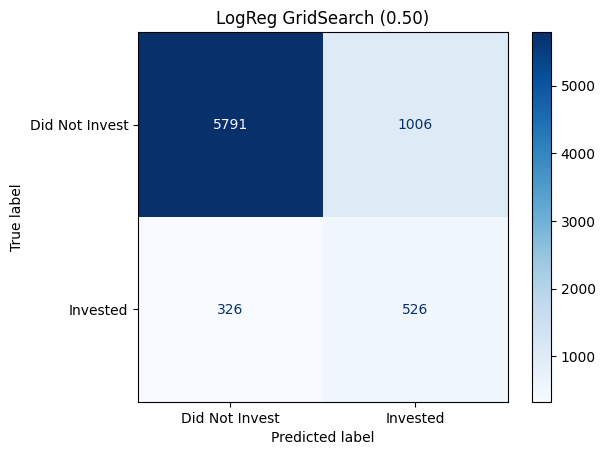

                precision    recall  f1-score   support

Did Not Invest      0.947     0.852     0.897      6797
      Invested      0.343     0.617     0.441       852

      accuracy                          0.826      7649
     macro avg      0.645     0.735     0.669      7649
  weighted avg      0.879     0.826     0.846      7649



In [134]:
evaluate(best_pipeline, X_test_log, y_test, "LogReg GridSearch (0.50)")

## LogReg GridSearch Threshold Tuned

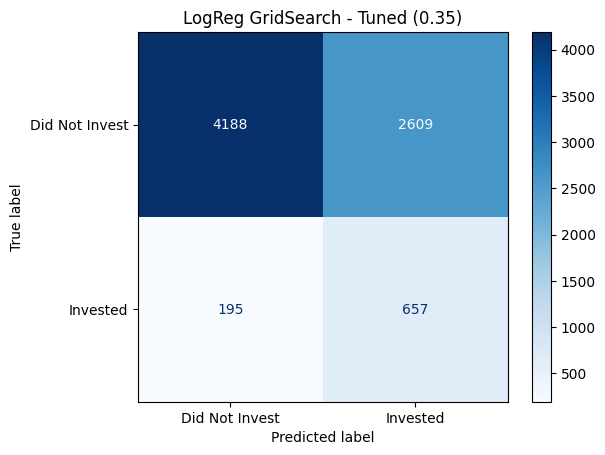

                precision    recall  f1-score   support

Did Not Invest       0.96      0.62      0.75      6797
      Invested       0.20      0.77      0.32       852

      accuracy                           0.63      7649
     macro avg       0.58      0.69      0.53      7649
  weighted avg       0.87      0.63      0.70      7649



In [135]:
evaluate_tune(0.35, y_prob, y_test, "LogReg GridSearch - Tuned (0.35)")

## Final LogReg Comparison

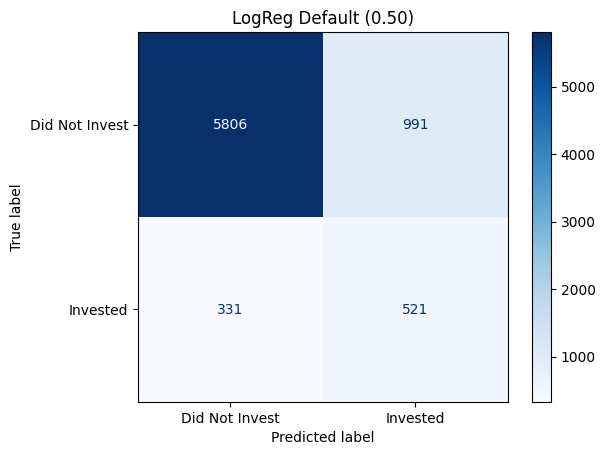

                precision    recall  f1-score   support

Did Not Invest      0.946     0.854     0.898      6797
      Invested      0.345     0.612     0.441       852

      accuracy                          0.827      7649
     macro avg      0.645     0.733     0.669      7649
  weighted avg      0.879     0.827     0.847      7649



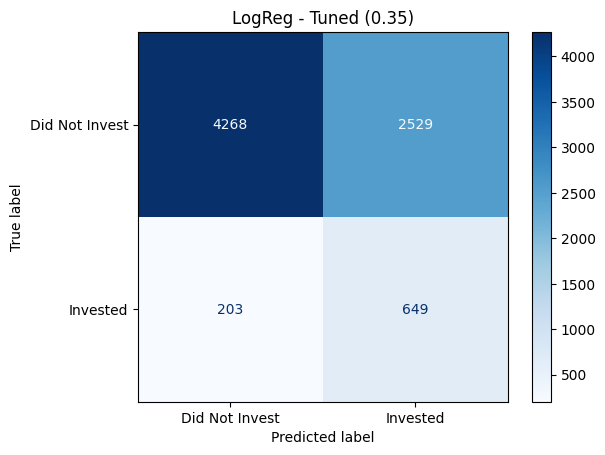

                precision    recall  f1-score   support

Did Not Invest       0.95      0.63      0.76      6797
      Invested       0.20      0.76      0.32       852

      accuracy                           0.64      7649
     macro avg       0.58      0.69      0.54      7649
  weighted avg       0.87      0.64      0.71      7649



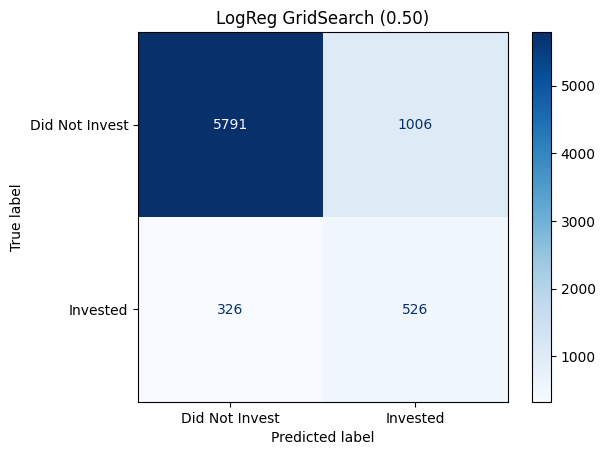

                precision    recall  f1-score   support

Did Not Invest      0.947     0.852     0.897      6797
      Invested      0.343     0.617     0.441       852

      accuracy                          0.826      7649
     macro avg      0.645     0.735     0.669      7649
  weighted avg      0.879     0.826     0.846      7649



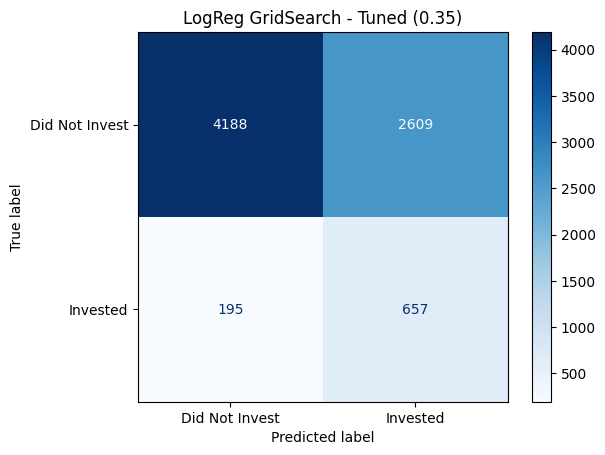

                precision    recall  f1-score   support

Did Not Invest       0.96      0.62      0.75      6797
      Invested       0.20      0.77      0.32       852

      accuracy                           0.63      7649
     macro avg       0.58      0.69      0.53      7649
  weighted avg       0.87      0.63      0.70      7649



In [136]:
evaluate(log_pipeline, X_test_log, y_test, "LogReg Default (0.50)")
ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, y_pred_tuned),
    display_labels=['Did Not Invest', 'Invested']
).plot(cmap='Blues')
plt.title('LogReg - Tuned (0.35)')
plt.show()
print(classification_report(y_test, y_pred_tuned, target_names=['Did Not Invest', 'Invested']))
evaluate(best_pipeline, X_test_log, y_test, "LogReg GridSearch (0.50)")
evaluate_tune(0.35, y_prob, y_test, "LogReg GridSearch - Tuned (0.35)")

# Random Forest
Tree-based models don't need scaling. We one-hot encode categoricals and reuse the same train/test split.

In [137]:
# Train Test Split
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True, dtype=int)

X_train_rf, X_test_rf, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Evaluation function
def evaluate(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    print(f"\n{name}")
    print(classification_report(y_test, y_pred, digits=3))
    print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
    print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.3f}")
    print(f"PR-AUC:  {average_precision_score(y_test, y_proba):.3f}")

## Random Forest Model 1

In [138]:
# Train & fit model 1
rf1 = RandomForestClassifier(
    n_estimators=300, 
    max_depth=None, 
    min_samples_leaf=2,
    class_weight='balanced',
    n_jobs=-1, 
    random_state=42,
)
rf1.fit(X_train_rf, y_train)

# Results
evaluate(rf1, X_test_rf, y_test, "Random Forest (0.50)")


Random Forest (0.50)
              precision    recall  f1-score   support

           0      0.937     0.926     0.931      6797
           1      0.459     0.500     0.479       852

    accuracy                          0.879      7649
   macro avg      0.698     0.713     0.705      7649
weighted avg      0.883     0.879     0.881      7649

Confusion matrix:
 [[6295  502]
 [ 426  426]]
ROC-AUC: 0.787
PR-AUC:  0.456


## Random Forest Model 2 

In [139]:
# Train & fit model 2
rf2 = RandomForestClassifier(
    n_estimators=500, 
    max_depth=12, 
    min_samples_leaf=10,
    class_weight='balanced', 
    n_jobs=-1,
    random_state=42,
)
rf2.fit(X_train_rf, y_train)

# Results
evaluate(rf2, X_test_rf, y_test, "Random Forest Model 2 (0.50)")


Random Forest Model 2 (0.50)
              precision    recall  f1-score   support

           0      0.947     0.882     0.913      6797
           1      0.392     0.607     0.476       852

    accuracy                          0.851      7649
   macro avg      0.670     0.744     0.695      7649
weighted avg      0.885     0.851     0.865      7649

Confusion matrix:
 [[5996  801]
 [ 335  517]]
ROC-AUC: 0.801
PR-AUC:  0.471


## Random Forest GridSearch 
Using GridSearchCV, we can systematically search for the best hyperparameters for the random forest model rather than manually tuning or guessing. GridSearchCV will allow us to do this and test the models using cross-validation.

In [140]:
# Setup GridSearchCV
rf_param_grid = {
    'n_estimators': [300, 500],
    'max_depth': [6, 8, 12, None],
    'min_samples_leaf': [2, 10, 15, 20]
}

# Train RF with GridSearchCV
rf_grid = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42),
    rf_param_grid,
    cv=3,
    scoring='roc_auc', 
    n_jobs=-1,
    verbose=1
)
rf_grid.fit(X_train_rf, y_train)
best_pipeline_rf = rf_grid.best_estimator_

# Evaluate best RF model
print("Best Params:", rf_grid.best_params_)
print(f"Best CV Recall: {rf_grid.best_score_:.4f}")
evaluate(best_pipeline_rf, X_test_rf, y_test, "Random Forest GridSearch (0.50)")

Fitting 3 folds for each of 32 candidates, totalling 96 fits
Best Params: {'max_depth': 12, 'min_samples_leaf': 15, 'n_estimators': 500}
Best CV Recall: 0.7967

Random Forest GridSearch (0.50)
              precision    recall  f1-score   support

           0      0.947     0.877     0.911      6797
           1      0.384     0.610     0.471       852

    accuracy                          0.847      7649
   macro avg      0.666     0.744     0.691      7649
weighted avg      0.884     0.847     0.862      7649

Confusion matrix:
 [[5962  835]
 [ 332  520]]
ROC-AUC: 0.801
PR-AUC:  0.468


## Random Forest GridSearch Threshold Tuned

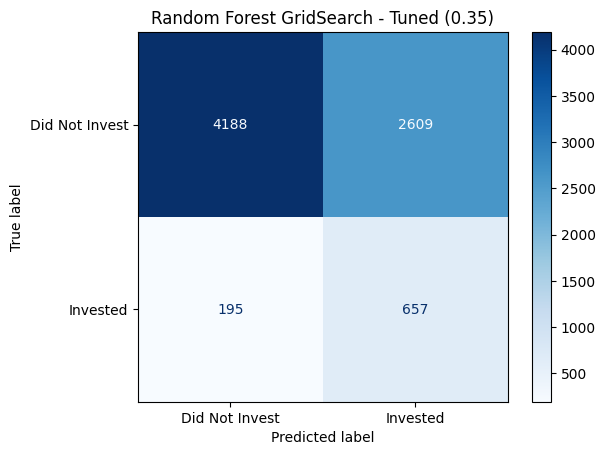

                precision    recall  f1-score   support

Did Not Invest       0.96      0.62      0.75      6797
      Invested       0.20      0.77      0.32       852

      accuracy                           0.63      7649
     macro avg       0.58      0.69      0.53      7649
  weighted avg       0.87      0.63      0.70      7649



In [141]:
evaluate_tune(0.35, y_prob, y_test, "Random Forest GridSearch - Tuned (0.35)")

## Final Random Forest Comparison


Random Forest (0.50)
              precision    recall  f1-score   support

           0      0.937     0.926     0.931      6797
           1      0.459     0.500     0.479       852

    accuracy                          0.879      7649
   macro avg      0.698     0.713     0.705      7649
weighted avg      0.883     0.879     0.881      7649

Confusion matrix:
 [[6295  502]
 [ 426  426]]
ROC-AUC: 0.787
PR-AUC:  0.456

Random Forest Model 2 (0.50)
              precision    recall  f1-score   support

           0      0.947     0.882     0.913      6797
           1      0.392     0.607     0.476       852

    accuracy                          0.851      7649
   macro avg      0.670     0.744     0.695      7649
weighted avg      0.885     0.851     0.865      7649

Confusion matrix:
 [[5996  801]
 [ 335  517]]
ROC-AUC: 0.801
PR-AUC:  0.471

Random Forest GridSearch (0.50)
              precision    recall  f1-score   support

           0      0.947     0.877     0.911      6797


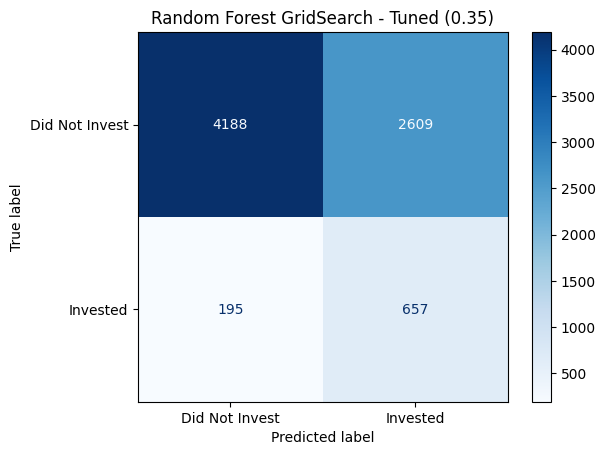

                precision    recall  f1-score   support

Did Not Invest       0.96      0.62      0.75      6797
      Invested       0.20      0.77      0.32       852

      accuracy                           0.63      7649
     macro avg       0.58      0.69      0.53      7649
  weighted avg       0.87      0.63      0.70      7649



In [142]:
evaluate(rf1, X_test_rf, y_test, "Random Forest (0.50)")
evaluate(rf2, X_test_rf, y_test, "Random Forest Model 2 (0.50)")
evaluate(best_pipeline_rf, X_test_rf, y_test, "Random Forest GridSearch (0.50)")
evaluate_tune(0.35, y_prob, y_test, "Random Forest GridSearch - Tuned (0.35)")

GridSearchCV showed that we already had strong hyperparameters in Model 2, with the search returning nearly identical results. The threshold tuning proved to be effective in increasing recall, which correctly identified 105 additional investors that the default threshold would have missed. When we later compare this to our logistic regression, we can compare the precision and recall tradeoff to evaluate which model will be more valuable in our business context.